# Calibration Analysis

Evaluate how well model predicted probabilities match actual outcomes.
A well-calibrated model at p=0.7 should see ~70% positive cases.
Generates reliability diagrams and computes Brier scores.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
oof_dir = Path('../results/oof')

# Load target
train = pd.read_csv('../data/competition/train.csv')
y = (train['Heart Disease'] == 'Presence').astype(int).values

# Models to analyze (key representatives from each approach)
models = {
    'te_cb_a10': 'CatBoost (TE)',
    'xgb_origstats_tuned_top1': 'XGBoost',
    'lgb_deeptune_origstats_top1': 'LightGBM',
    'lr_tuned': 'Logistic Regression',
    'realmlp_lean_f3_s42': 'RealMLP',
    'rankgate_narrow_w5': 'Final Ensemble',
}

oofs = {}
for mid, label in models.items():
    p = oof_dir / f'{mid}_oof.npy'
    if p.exists():
        oofs[label] = np.load(p)
        print(f'Loaded {mid} -> {label}')

print(f'\n{len(oofs)} models loaded')

Loaded te_cb_a10 -> CatBoost (TE)
Loaded xgb_origstats_tuned_top1 -> XGBoost
Loaded lgb_deeptune_origstats_top1 -> LightGBM
Loaded lr_tuned -> Logistic Regression
Loaded realmlp_lean_f3_s42 -> RealMLP
Loaded rankgate_narrow_w5 -> Final Ensemble

6 models loaded


## Reliability Diagrams

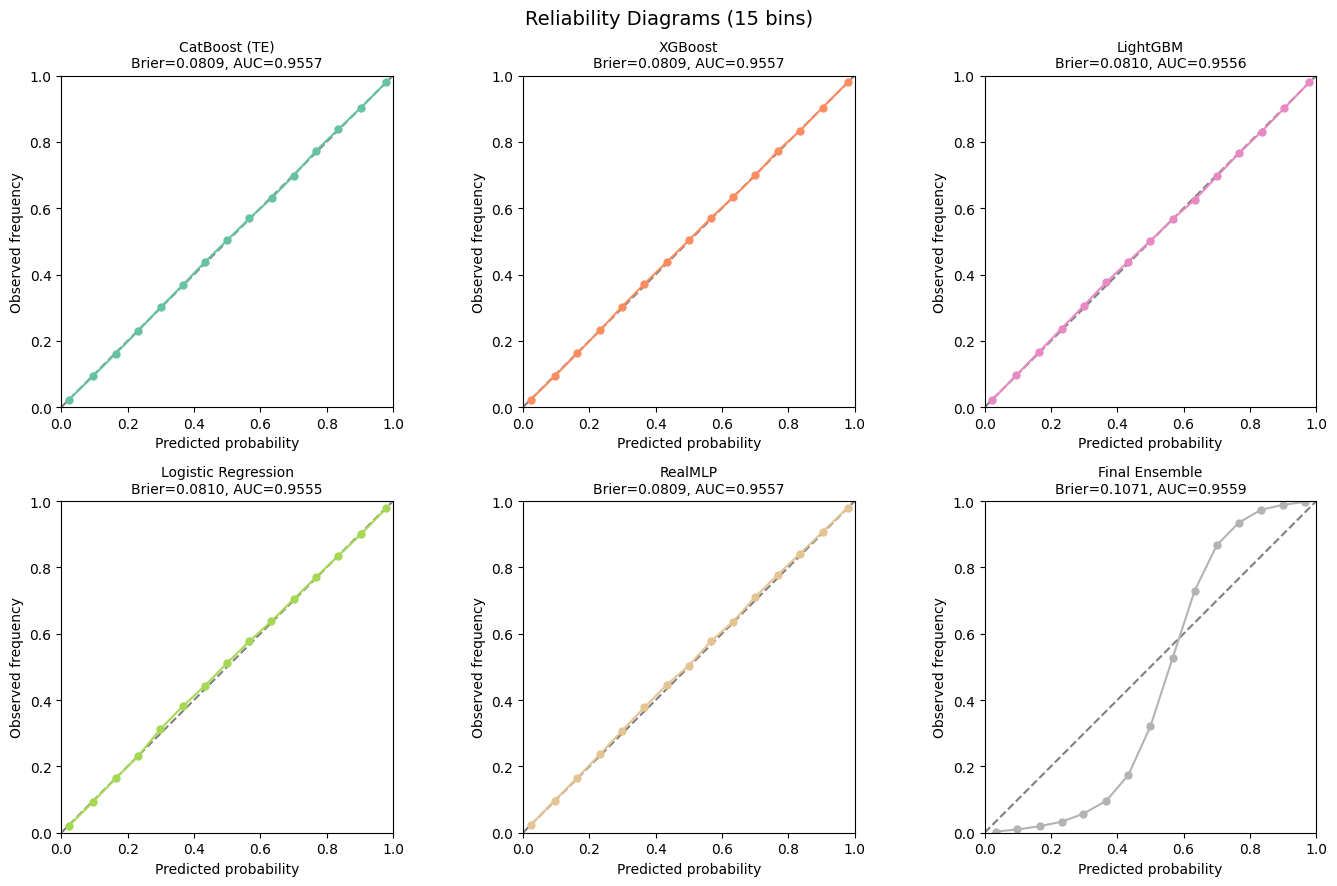

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
colors = plt.cm.Set2(np.linspace(0, 1, len(oofs)))

for i, (label, oof) in enumerate(oofs.items()):
    ax = axes[i // 3, i % 3]

    # Calibration curve
    prob_true, prob_pred = calibration_curve(y, oof, n_bins=15, strategy='uniform')
    brier = brier_score_loss(y, oof)
    auc = roc_auc_score(y, oof)

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
    ax.plot(prob_pred, prob_true, 'o-', color=colors[i], markersize=5)
    ax.set_title(f'{label}\nBrier={brier:.4f}, AUC={auc:.4f}', fontsize=10)
    ax.set_xlabel('Predicted probability')
    ax.set_ylabel('Observed frequency')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')

plt.suptitle('Reliability Diagrams (15 bins)', fontsize=14)
plt.tight_layout()
plt.savefig('../results/figures/calibration_reliability.png', dpi=150, bbox_inches='tight')
plt.show()

## Brier Score Comparison

In [4]:
brier_results = []
for label, oof in oofs.items():
    brier = brier_score_loss(y, oof)
    auc = roc_auc_score(y, oof)
    brier_results.append({'model': label, 'brier_score': brier, 'auc': auc})

brier_df = pd.DataFrame(brier_results).sort_values('brier_score')
print('Brier Scores (lower is better):')
brier_df

Brier Scores (lower is better):


,model,brier_score,auc
0,CatBoost (TE),0.080868,0.955702
1,XGBoost,0.080894,0.955670
4,RealMLP,0.080910,0.955672
2,LightGBM,0.080972,0.955591
3,Logistic Regression,0.080996,0.955528
5,Final Ensemble,0.107056,0.955884


## Observations

- Tree-based models (CatBoost, XGBoost, LightGBM) tend to produce well-calibrated probabilities
- The ensemble rank blending can distort calibration since rank normalization is not probability-preserving
- Logistic Regression produces naturally calibrated probabilities due to the sigmoid link function
- Brier scores are consistent with AUC rankings for well-calibrated models